# Decoding Analysis

Applies PCA to activity data to obtain decoding manifolds (averaged over time) and decoding trajectories (dynamics over time).

In [1]:
import pickle
import logging

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import lsq_linear
from scipy.sparse import load_npz
from scipy.spatial.distance import squareform, pdist, cdist
import tueplots
from tueplots import bundles
from tueplots.constants.color import rgb
from sklearn.decomposition import PCA
import plotly.graph_objects as go

import sys, os; _d = os.path.abspath(os.getcwd()); sys.path.insert(0, _d if os.path.isdir(os.path.join(_d, 'src')) else os.path.dirname(_d))
from src import *

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams.update(bundles.neurips2021(usetex=False))

results_dict = {}


In [2]:
PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_seed2"; low_sf = False

#PREFIX = "flyvis_Retina_i3_n400_model000"; low_sf = True
#PREFIX = "flyvis_Lamina_i3_n350_model000"; low_sf = True
#PREFIX = "flyvis_Medulla_i3_n550_model000"; low_sf = True
#PREFIX = "flyvis_T_Tm_i3_n1700_model000"; low_sf = True

#PREFIX = "VISp_natural_movie_one_scenes20"; low_sf = None

#PREFIX = "Retina"; low_sf = True
#PREFIX = "V1"; low_sf = True

#PREFIX = "res50_shifted_act_i3_n1000_SCL0_5_TL37_layer1_maxFr_maxNr_seed1"; low_sf = False
PREFIX = "res50_shifted_act_i3_n1000_SCL0_5_TL37_layer4_maxFr_maxNr_seed1"; low_sf = False

# Stimulus-index slices for the 11-stim tensor:
#   low_sf=True  → first 6 stims: 3 gratings + 3 low-SF dot flows
#   low_sf=False → remaining 6: indices 0 (LF-grat) + 6–10 (high-SF variants)
LOW_SF_INDICES  = slice(0, 6)            # stimuli 0–5: low spatial frequency set
HIGH_SF_INDICES = np.array([0, 6, 7, 8, 9, 10])  # LF-grat plus high-SF stimuli

# Ensure output figure directories exist
os.makedirs('../fig/decoding_manifolds', exist_ok=True)
os.makedirs('../fig/decoding_trajectories', exist_ok=True)


## Load activity data

In [3]:
basedir = '../data/sampled'

if PREFIX == "V1":
    tensor4d = np.load("../data/biological/V1_tensor_traces.npy")
elif PREFIX == "Retina":
    tensor4d = np.load("../data/biological/retina_tensor_traces.npy")
else:
    tensor4d = np.load(f'{basedir}/tensor4d_{PREFIX}.npy')

n_neurons, n_stim, n_ori, trial_len = tensor4d.shape

if low_sf is None or n_stim != 11:
    pass  # use all stimuli as-is
elif low_sf:
    tensor4d = tensor4d[:, LOW_SF_INDICES]
    n_neurons, n_stim, n_ori, trial_len = tensor4d.shape
else:
    tensor4d = tensor4d[:, HIGH_SF_INDICES]
    n_neurons, n_stim, n_ori, trial_len = tensor4d.shape

print(f"(Neurons, Stimuli, Orientation, Trial len): {tensor4d.shape}")


(Neurons, Stimuli, Orientation, Trial len): (1000, 6, 8, 37)


In [4]:
# For trajectories
transposed = np.transpose(tensor4d, (3, 1, 2, 0))
reshaped = transposed.reshape(-1, len(tensor4d))
print(reshaped.shape)

# sklearn PCA may emit numerical warnings (divide by zero / overflow / invalid)
# on near-zero rows that occur in some layers — these are expected and can be ignored.
pca_traj = PCA(n_components=3)
pca_traj_result = pca_traj.fit_transform(reshaped)
pc1_loadings = pca_traj.components_[0]

reshaped_traj_result = pca_traj_result.reshape(tensor4d.shape[3], n_stim*n_ori, -1)
trajectories = np.transpose(reshaped_traj_result, (1, 0, 2))


# For Decoding Manifold: Meaned traces
first_n_points = tensor4d.shape[3]

meaned = np.mean(transposed[:first_n_points], axis=0)
reshaped = meaned.reshape(-1, len(tensor4d))

pca_decoding = PCA(n_components=3)
pca_decoding_result = pca_decoding.fit_transform(reshaped)
print(np.sum(pca_decoding.explained_variance_ratio_))

reshaped_decoding_result = pca_decoding_result.reshape(n_stim*n_ori, -1)


(1776, 1000)
0.721535759542565


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-

## Decoding Manifold

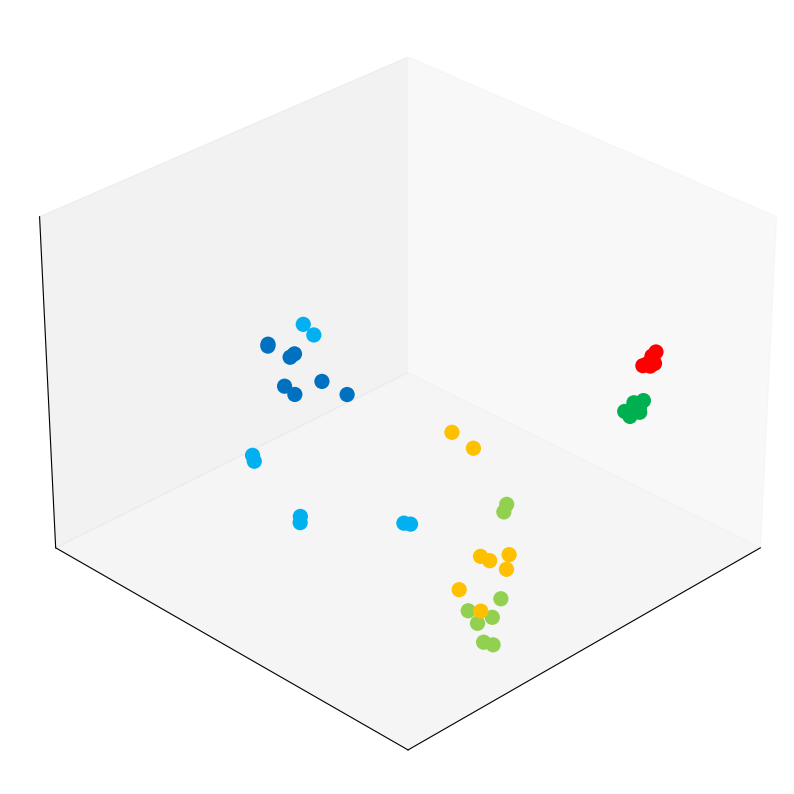

In [5]:
import math as _math

_KNOWN_STIM_LABELS = {
    6:  ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot'],
    11: ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
         'HF-grat-2', '-1dot-2', '-3dot-2', '+1dot-2', '+3dot-2'],
}
_PALETTE = ['#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
            '#7030A0', '#FF6600', '#339933', '#CC0066', '#009999', '#996633']

labels = _KNOWN_STIM_LABELS.get(n_stim, [f'stim {i}' for i in range(n_stim)])
stimulus_colors = (_PALETTE * _math.ceil(n_stim / len(_PALETTE)))[:n_stim]

n_per_label = n_ori
clrs = []
legend_labels = []
for i in range(n_stim):
    clrs.extend([stimulus_colors[i]] * n_per_label)
    legend_labels.extend([labels[i]] * n_per_label)
clrs = np.array(clrs)
legend_labels = np.array(legend_labels)

# Create Matplotlib Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each group
for i, label in enumerate(labels):
    mask = (legend_labels == label)
    if np.any(mask):
        ax.scatter(
            reshaped_decoding_result[mask, 0],
            reshaped_decoding_result[mask, 1],
            reshaped_decoding_result[mask, 2],
            color=stimulus_colors[i],
            s=120,
            label=label,
            alpha=1.0,
            edgecolors='none'
        )

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev=30, azim=45)

plt.savefig(f'../fig/decoding_manifolds/{PREFIX}_decoding.pdf', format='pdf', bbox_inches='tight', dpi=300)

## Plot Trajectories and Crossings

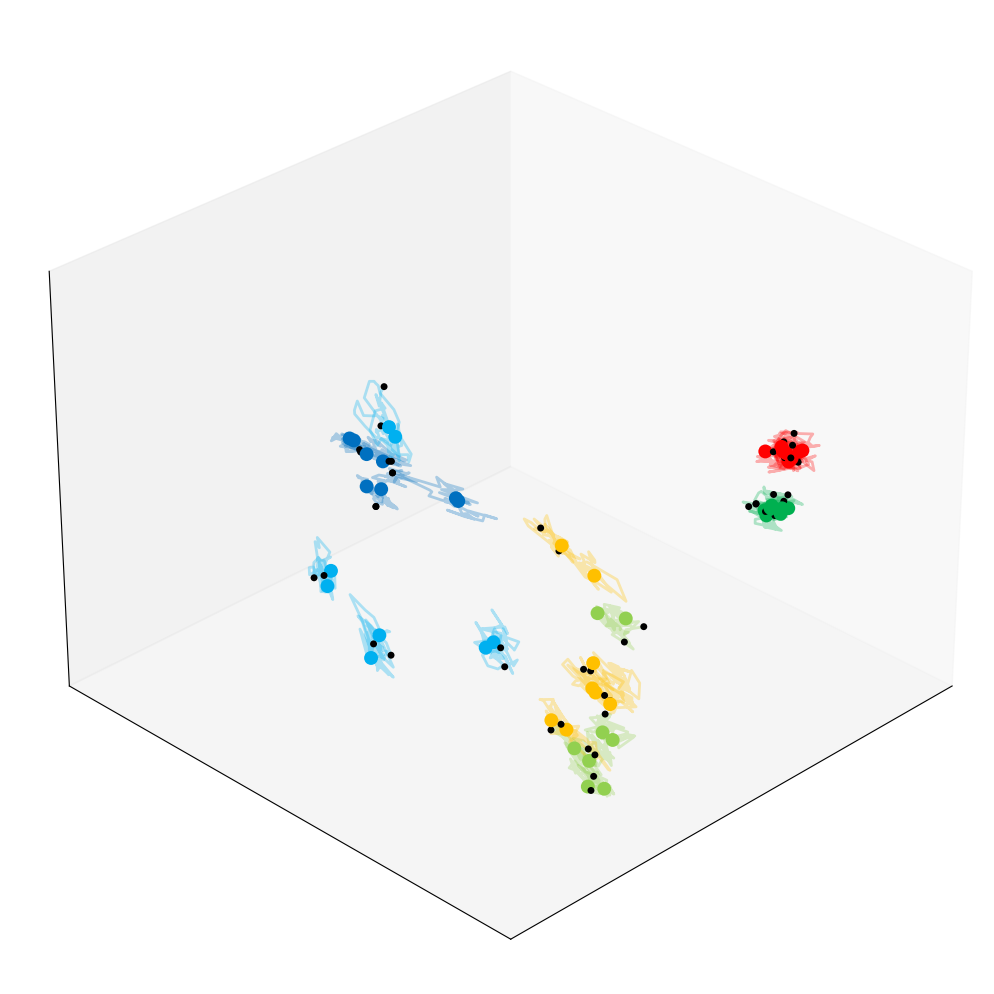

Saved to ../fig/decoding_trajectories/crossings_res50_shifted_act_i3_n1000_SCL0_5_TL37_layer4_maxFr_maxNr_seed1.pdf


In [6]:
def plot_trajectories_matplotlib(trajectories, prefix="prefix", filename="filename",
                                 stimulus_colors=None, n_ori=8):
    """
    Plot 3D trajectories using Matplotlib (Vector/PDF safe).
    """
    # 1. Setup Colors and Names
    if stimulus_colors is None:
        stimulus_colors = [
            '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
            '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000'
        ]

    # 2. Initialize Figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Plot Loop
    for i, traj in enumerate(trajectories):
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2] * 0.5  # z * 0.5: cosmetic scale to reduce depth distortion

        # Determine grouping
        stimulus_idx = i // n_ori
        stimulus_color = stimulus_colors[stimulus_idx % len(stimulus_colors)]

        # A. Plot the Trajectory Line
        ax.plot(
            x, y, z,
            color=stimulus_color,
            linewidth=2,
            alpha=0.3
        )

        # B. Start Point (Black)
        ax.scatter(
            x[0], y[0], z[0],
            color='black',
            s=25,
            depthshade=False,
            edgecolors='none'
        )

        # C. End Point (Stimulus Colored)
        ax.scatter(
            x[-1], y[-1], z[-1],
            color=stimulus_color,
            s=100,
            depthshade=False,
            edgecolors='none'
        )

    # 4. Styling
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.xaxis.line.set_color('black')
    ax.yaxis.line.set_color('black')
    ax.zaxis.line.set_color('black')
    ax.view_init(elev=30, azim=45)

    # 5. Save
    output_path = f'../fig/decoding_trajectories/crossings_{prefix}.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved to {output_path}")

# Usage:
plot_trajectories_matplotlib(trajectories, prefix=PREFIX,
                             stimulus_colors=stimulus_colors, n_ori=n_ori)
